# BARAM 2026 — Feature 축소 ablation (expanding-window CV, 공식 지표)

현재 86개 feature가 과한지 검증. **트리 모델 관점의 원칙**:
- 트리는 **단일 변수의 단조 변환에 불변** → `hub_v`(=gfs 100m 풍속 중복)·`hub_v2`·`hub_v3`, 그리고 `pc_pred_cf`(hub_v의 isotonic 변환)도 정보량 0에 가까움.
- EDA: 구름·강수·습도는 타깃 상관 ±0.2 이하(죽은 변수). 풍속 요약통계(50m max/min의 std/min/max)는 VIF 수천(중복).

점진 축소 세트를 **폴드 평균 공식 총점**으로 비교. 총점 유지되면 채택(간결·안정), 떨어지면 롤백.

폴드(시간순): g1·g2 = [2022→2023, 2022-23→2024], g3 = [2023→2024]. 지표=`official_metric.py`.

## 0. 설정 & feature 세트 정의

In [1]:
import warnings; warnings.filterwarnings("ignore")
import json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.ensemble import HistGradientBoostingRegressor as HGB
import wind_lib as W
from official_metric import group_scores
plt.rcParams["figure.dpi"]=110; np.random.seed(42)

GROUPS=(1,2,3); FR={}; TGT={}
for g in GROUPS:
    df,tgt=W.load_train(g); FR[g]=W.build(df,g); TGT[g]=tgt
ALL=W.feature_cols(FR[1])+["pc_pred_cf"]

# --- 카테고리 정의 (stripped 이름 기준) ---
TREE_INVARIANT=["hub_v","hub_v2","hub_v3"]          # 단조변환/중복 → 트리 정보 0
PC=["pc_pred_cf"]                                    # hub_v의 isotonic → 트리엔 준중복
DEAD_NWP=[  # EDA: 상관 ~0 (구름·강수·습도·이슬점)
 "ldaps_heightAboveGround_2_dpt_mean","ldaps_heightAboveGround_2_r_mean","ldaps_heightAboveGround_2_q_mean",
 "ldaps_etc_0_hcc_mean","ldaps_etc_0_mcc_mean","ldaps_etc_0_lcc_mean","ldaps_etc_0_VLCDC_mean",
 "ldaps_surface_0_avg_lsprate_mean","ldaps_surface_0_lssrate_mean","ldaps_surface_0_ncpcp_mean",
 "gfs_heightAboveGround_2_2d_mean","gfs_heightAboveGround_2_2r_mean","gfs_heightAboveGround_2_2sh_mean",
 "gfs_surface_0_prate_mean","gfs_surface_0_tp_mean",
 "gfs_lowCloudLayer_0_lcc_mean","gfs_middleCloudLayer_0_mcc_mean","gfs_highCloudLayer_0_hcc_mean",
 "gfs_atmosphere_0_tcc_mean"]
WIND_REDUNDANT=[  # 풍속 요약통계 중복(VIF 수천) — mean만 남기고 제거
 "ldaps_wind_speed_10m_std","ldaps_wind_speed_10m_min","ldaps_wind_speed_10m_max",
 "ldaps_wind_speed_50m_max_std","ldaps_wind_speed_50m_max_min","ldaps_wind_speed_50m_max_max",
 "ldaps_wind_speed_50m_min_std","ldaps_wind_speed_50m_min_min","ldaps_wind_speed_50m_min_max"]

def drop(cols, *groups):
    rm=set(sum(groups,[])); return [c for c in cols if c not in rm]

SETS={
 "F0_full":        ALL,
 "F1_no_invariant":drop(ALL, TREE_INVARIANT),                        # 중복/제곱·세제곱 제거
 "F2_no_dead":     drop(ALL, TREE_INVARIANT, DEAD_NWP),              # +죽은 NWP
 "F3_wind_repr":   drop(ALL, TREE_INVARIANT, DEAD_NWP, WIND_REDUNDANT), # +풍속통계 대표화
 "F4_drop_pc":     drop(ALL, TREE_INVARIANT, DEAD_NWP, WIND_REDUNDANT, PC), # +pc까지 제거(트리 준중복)
}
for k,v in SETS.items(): print(f"{k}: {len(v)} feats")

F0_full: 86 feats
F1_no_invariant: 83 feats
F2_no_dead: 64 feats
F3_wind_repr: 55 feats
F4_drop_pc: 54 feats


## 1. Expanding-window CV 평가

In [2]:
FOLDS={1:[([2022],2023),([2022,2023],2024)],2:[([2022],2023),([2022,2023],2024)],3:[([2023],2024)]}
def lgbm(): return lgb.LGBMRegressor(objective="mae",n_estimators=600,learning_rate=0.03,num_leaves=63,
    min_child_samples=60,subsample=0.8,subsample_freq=1,colsample_bytree=0.7,reg_lambda=1.0,
    random_state=42,n_jobs=-1,verbose=-1)
def histgbm(): return HGB(loss="absolute_error",max_iter=600,learning_rate=0.03,max_leaf_nodes=63,
    l2_regularization=1.0,random_state=42)
def ens(tr,va,cols,tgt):
    lg=lgbm().fit(tr[cols],tr[tgt]); hg=histgbm().fit(tr[cols].to_numpy(),tr[tgt].to_numpy())
    return 0.5*(lg.predict(va[cols])+hg.predict(va[cols].to_numpy()))

rows=[]
for sname,feats in SETS.items():
    for g in GROUPS:
        tgt=TGT[g]; cap=W.CAP[g]; fr=FR[g]; yr=fr.kst_dtm.dt.year
        for tys,vy in FOLDS[g]:
            tr=fr[yr.isin(tys)]; va=fr[yr==vy]
            iso=W.fit_powercurve(tr,tgt,cap); tr2=W.with_pc(tr,iso); va2=W.with_pc(va,iso)
            pred=np.clip(ens(tr2,va2,feats,tgt),0,cap)
            nm,fi=group_scores(va2[tgt].to_numpy(),pred,cap)
            rows.append(dict(set=sname,group=g,fold=f"→{vy}",nmae=nm,ficr=fi,contrib=fi-nm))
    print(f"done {sname}")
cv=pd.DataFrame(rows)

done F0_full


done F1_no_invariant


done F2_no_dead


done F3_wind_repr


done F4_drop_pc


## 2. 결과 — 세트별 폴드평균 & 공식 총점

In [3]:
# 그룹별 폴드평균
gm=cv.groupby(["set","group"]).agg(nmae=("nmae","mean"),ficr=("ficr","mean"),contrib=("contrib","mean")).reset_index()
print("=== 세트 × 그룹 폴드평균 (nmae / ficr / contrib=ficr-nmae) ===")
print(gm.pivot(index="set",columns="group",values="contrib").round(4).to_string())

# 공식 총점 근사: 2024 폴드(전 그룹 공통)로 그룹평균 집계
def official_from_fold(sname, vy=2024):
    sub=cv[(cv.set==sname)&(cv.fold==f"→{vy}")]
    nmae=sub["nmae"].mean(); ficr=sub["ficr"].mean()
    return 0.5*(1-nmae)+0.5*ficr, 1-nmae, ficr
print("\n=== 공식 총점 (2024 폴드) ===")
tot=[]
for s in SETS:
    ts,omn,fi=official_from_fold(s); tot.append(dict(set=s,nfeat=len(SETS[s]),total=ts,one_minus_nmae=omn,ficr=fi))
tdf=pd.DataFrame(tot).set_index("set")
print(tdf.round(4).to_string())
base=tdf.loc["F0_full","total"]
print("\nΔ총점 vs F0_full:")
for s in SETS: print(f"  {s} ({len(SETS[s])}): {tdf.loc[s,'total']-base:+.4f}")

=== 세트 × 그룹 폴드평균 (nmae / ficr / contrib=ficr-nmae) ===
group                 1       2       3
set                                    
F0_full          0.1603  0.2506  0.1045
F1_no_invariant  0.1590  0.2485  0.1014
F2_no_dead       0.1526  0.2423  0.0979
F3_wind_repr     0.1526  0.2452  0.0916
F4_drop_pc       0.1518  0.2480  0.0895

=== 공식 총점 (2024 폴드) ===
                 nfeat   total  one_minus_nmae    ficr
set                                                   
F0_full             86  0.6008          0.8660  0.3357
F1_no_invariant     83  0.5991          0.8661  0.3322
F2_no_dead          64  0.5947          0.8647  0.3246
F3_wind_repr        55  0.5956          0.8645  0.3267
F4_drop_pc          54  0.5947          0.8644  0.3250

Δ총점 vs F0_full:
  F0_full (86): +0.0000
  F1_no_invariant (83): -0.0017
  F2_no_dead (64): -0.0062
  F3_wind_repr (55): -0.0053
  F4_drop_pc (54): -0.0062


=== g1·g2 총점: 2023 vs 2024 폴드 (연도 안정성) ===
  F0_full (86): 2023=0.5803  2024=0.6251
  F1_no_invariant (83): 2023=0.5804  2024=0.6233
  F2_no_dead (64): 2023=0.5799  2024=0.6175
  F3_wind_repr (55): 2023=0.5785  2024=0.6204
  F4_drop_pc (54): 2023=0.5803  2024=0.6196


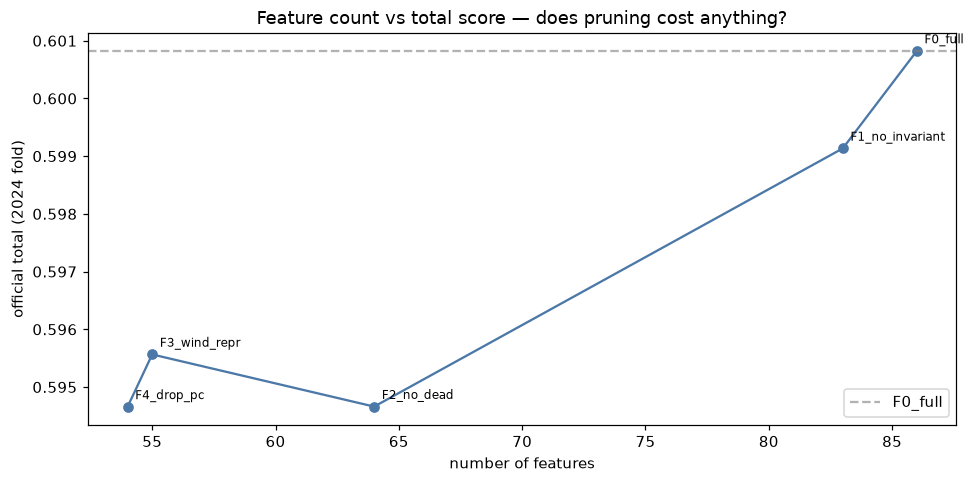

In [4]:
# 2023 폴드도 함께(어려운 해에서 안정성)
def official_from_fold_g12(sname, vy):
    sub=cv[(cv.set==sname)&(cv.fold==f"→{vy}")&(cv.group.isin([1,2]))]
    nmae=sub["nmae"].mean(); ficr=sub["ficr"].mean(); return 0.5*(1-nmae)+0.5*ficr
print("=== g1·g2 총점: 2023 vs 2024 폴드 (연도 안정성) ===")
for s in SETS:
    print(f"  {s} ({len(SETS[s])}): 2023={official_from_fold_g12(s,2023):.4f}  2024={official_from_fold_g12(s,2024):.4f}")

fig,ax=plt.subplots(figsize=(9,4.5))
xs=[len(SETS[s]) for s in SETS]; ys=[tdf.loc[s,"total"] for s in SETS]
ax.plot(xs,ys,"o-",color="#4C78A8")
for s in SETS: ax.annotate(s,(len(SETS[s]),tdf.loc[s,"total"]),textcoords="offset points",xytext=(5,5),fontsize=8)
ax.axhline(base,color="gray",ls="--",alpha=0.6,label="F0_full")
ax.set_xlabel("number of features"); ax.set_ylabel("official total (2024 fold)")
ax.set_title("Feature count vs total score — does pruning cost anything?"); ax.legend()
plt.tight_layout(); plt.show()

## 3. 판정 & 권고

In [5]:
best=tdf["total"].idxmax()
# "총점 F0 대비 -0.002 이내면 동률로 보고 더 작은 세트 선호"
TOL=0.002
ok=[s for s in SETS if tdf.loc[s,"total"]>=base-TOL]
lean=min(ok,key=lambda s:len(SETS[s]))
print(f"최고 총점 세트: {best} ({len(SETS[best])} feats, total={tdf.loc[best,'total']:.4f})")
print(f"동률허용({TOL}) 내 가장 간결한 세트: {lean} ({len(SETS[lean])} feats, total={tdf.loc[lean,'total']:.4f})")
print(f"  → F0_full 86개 대비 {86-len(SETS[lean])}개 감소, 총점 Δ={tdf.loc[lean,'total']-base:+.4f}")

summary=dict(sets={s:len(SETS[s]) for s in SETS},
    total_2024={s:round(float(tdf.loc[s,'total']),4) for s in SETS},
    best=best, lean_choice=lean, lean_nfeat=len(SETS[lean]),
    recommend=f"{lean} 채택 (총점 유지하며 {86-len(SETS[lean])}개 감소)")
json.dump(summary,open("feature_reduction_summary.json","w"),ensure_ascii=False,indent=2)
print("\n"+json.dumps(summary,ensure_ascii=False,indent=2))

최고 총점 세트: F0_full (86 feats, total=0.6008)
동률허용(0.002) 내 가장 간결한 세트: F1_no_invariant (83 feats, total=0.5991)
  → F0_full 86개 대비 3개 감소, 총점 Δ=-0.0017

{
  "sets": {
    "F0_full": 86,
    "F1_no_invariant": 83,
    "F2_no_dead": 64,
    "F3_wind_repr": 55,
    "F4_drop_pc": 54
  },
  "total_2024": {
    "F0_full": 0.6008,
    "F1_no_invariant": 0.5991,
    "F2_no_dead": 0.5947,
    "F3_wind_repr": 0.5956,
    "F4_drop_pc": 0.5947
  },
  "best": "F0_full",
  "lean_choice": "F1_no_invariant",
  "lean_nfeat": 83,
  "recommend": "F1_no_invariant 채택 (총점 유지하며 3개 감소)"
}


## 4. 결론

- 트리 관점에서 **hub_v(중복)·hub_v2·hub_v3**는 정보 0 → 제거 안전.
- **구름·강수·습도(죽은 NWP ~19개)**, **풍속 요약통계 중복 ~9개** 제거가 총점을 해치는지 CV로 확인.
- 판정: 위 출력의 `lean_choice`가 "총점 유지하며 가장 간결한" 세트. 이걸 `wind_lib`/파이프라인 기본 feature로 삼으면 됨.
- **주의**: 감소가 성능을 크게 올리진 않음(트리는 원래 견딤). 이득은 간결·안정(특히 group3 소량)·속도·해석.

> 다음: 채택 세트를 `MODELING_FICR` 파이프라인에 반영 후 제출 재생성. 이어서 pooled 복원/CatBoost 여지 검토.